**Loading Data**

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

#base path
BASE = '/kaggle/input/datasets/elisabethwilliam/urbanev-shenzhen-zone'

#loading files
occupancy = pd.read_csv(f'{BASE}/occupancy.csv', index_col =0)
weather  = pd.read_csv(f'{BASE}/weather_airport.csv')
adj = pd.read_csv(f'{BASE}/adj.csv', index_col =0, header=0)
distance = pd.read_csv(f'{BASE}/distance.csv', index_col =0, header=0)
inf = pd.read_csv(f'{BASE}/inf.csv')
poi = pd.read_csv(f'{BASE}/poi.csv')

print("All files loaded.")
print(f"Zones: {occupancy.shape[1]}, Timesteps: {occupancy.shape[0]}")
print(f"inf shape: {inf.shape}, POI entries: {len(poi)}one")

All files loaded.
Zones: 275, Timesteps: 4344
inf shape: (1362, 7), POI entries: 712135one


**Zone ID Inspection**

In [2]:
#Zone IDs from occupancy columns
occ_zones = [int(c) for c in occupancy.columns]

#Zone IDs from inf
print("inf TAZID sample:", inf['TAZID'].values[:10])
print("occupancy zone sample:", occ_zones[:10])
print(f"\nZones in occupancy: {len(occ_zones)}")
print(f"Zones in inf: {len(inf)}")  

#overlap inspection
inf_zones = set(inf['TAZID'].values)
occ_zones_set = set(occ_zones)
print(f"\nZones in both: {len(inf_zones & occ_zones_set)}")
print(f"In occ bit not inf: {len(occ_zones_set - inf_zones)}")
print(f"In inf but not occ: {len(inf_zones - occ_zones_set)}")

inf TAZID sample: [559 558 558 596 594 596 595 595 594 598]
occupancy zone sample: [102, 104, 105, 106, 107, 108, 109, 110, 111, 115]

Zones in occupancy: 275
Zones in inf: 1362

Zones in both: 275
In occ bit not inf: 0
In inf but not occ: 0


**Temporal Feature Engineering**

In [3]:
# Parse datetime index
time_index = pd.to_datetime(occupancy.index)

temporal_features = pd.DataFrame({
    'hour':        time_index.hour,
    'day_of_week': time_index.dayofweek,   # 0=Mon, 6=Sun
    'month':       time_index.month,
    'is_weekend':  (time_index.dayofweek >= 5).astype(int),
    'is_peak':     time_index.hour.isin([7,8,9,17,18,19,20]).astype(int),
}, index=time_index)

# Cyclical encoding for hour and day (avoids discontinuity at midnight/week boundary)
temporal_features['hour_sin']    = np.sin(2 * np.pi * temporal_features['hour'] / 24)
temporal_features['hour_cos']    = np.cos(2 * np.pi * temporal_features['hour'] / 24)
temporal_features['dow_sin']     = np.sin(2 * np.pi * temporal_features['day_of_week'] / 7)
temporal_features['dow_cos']     = np.cos(2 * np.pi * temporal_features['day_of_week'] / 7)
temporal_features['month_sin']   = np.sin(2 * np.pi * temporal_features['month'] / 12)
temporal_features['month_cos']   = np.cos(2 * np.pi * temporal_features['month'] / 12)

print("Temporal features shape:", temporal_features.shape)
print(temporal_features.head())

Temporal features shape: (4344, 11)
                     hour  day_of_week  month  is_weekend  is_peak  hour_sin  \
time                                                                           
2022-09-01 00:00:00     0            3      9           0        0  0.000000   
2022-09-01 01:00:00     1            3      9           0        0  0.258819   
2022-09-01 02:00:00     2            3      9           0        0  0.500000   
2022-09-01 03:00:00     3            3      9           0        0  0.707107   
2022-09-01 04:00:00     4            3      9           0        0  0.866025   

                     hour_cos   dow_sin   dow_cos  month_sin     month_cos  
time                                                                        
2022-09-01 00:00:00  1.000000  0.433884 -0.900969       -1.0 -1.836970e-16  
2022-09-01 01:00:00  0.965926  0.433884 -0.900969       -1.0 -1.836970e-16  
2022-09-01 02:00:00  0.866025  0.433884 -0.900969       -1.0 -1.836970e-16  
2022-09-01 03:00:0

**POI density features per Zone**

In [4]:
# For each zone in inf, count POIs within a radius using lat/lon
# First check what POI types exist
print("POI primary_types:", poi['primary_types'].unique())
print(f"Total POIs: {len(poi)}")

POI primary_types: ['lifestyle services' 'business and residential'
 'food and beverage services']
Total POIs: 712135


**POI Density per zone**

In [5]:
from scipy.spatial import cKDTree

# Aggregate inf from station-level to zone-level (one row per TAZID)
inf_zone = inf.groupby('TAZID').agg(
    latitude    = ('latitude',     'mean'),
    longitude   = ('longitude',    'mean'),
    charge_count= ('charge_count', 'sum'),
    area        = ('area',         'first'),
    perimeter   = ('perimeter',    'first')
).reset_index()

# Filter to zones in occupancy and align order
inf_zone = inf_zone[inf_zone['TAZID'].isin(occ_zones)]
inf_zone = inf_zone.set_index('TAZID').loc[occ_zones]

print(f"Zone-level inf shape: {inf_zone.shape}")
print(inf_zone.head())

# Zone centroids (now 275 rows)
zone_coords = inf_zone[['latitude', 'longitude']].values
poi_coords  = poi[['latitude', 'longitude']].values

# Build KD-tree
poi_tree = cKDTree(poi_coords)

# POI type mapping
poi['type_code'] = poi['primary_types'].map({
    'lifestyle services':         0,
    'business and residential':   1,
    'food and beverage services': 2
})

# Count POIs per zone within radius
RADIUS = 0.02
type_names   = ['lifestyle', 'business_residential', 'food_beverage']
type_counts  = {name: [] for name in type_names}
total_counts = []

for lat, lon in zone_coords:
    idx    = poi_tree.query_ball_point([lat, lon], r=RADIUS)
    nearby = poi.iloc[idx]
    total_counts.append(len(idx))
    for code, name in enumerate(type_names):
        type_counts[name].append((nearby['type_code'] == code).sum())

poi_features = pd.DataFrame({
    'poi_total':    total_counts,
    'poi_lifestyle': type_counts['lifestyle'],
    'poi_business':  type_counts['business_residential'],
    'poi_food':      type_counts['food_beverage'],
}, index=occ_zones)

# Normalise
for col in ['poi_total', 'poi_lifestyle', 'poi_business', 'poi_food']:
    mn, mx = poi_features[col].min(), poi_features[col].max()
    poi_features[f'{col}_norm'] = (poi_features[col] - mn) / (mx - mn + 1e-8)

print(f"\nPOI features shape: {poi_features.shape}")
print(poi_features.describe().round(2))

Zone-level inf shape: (275, 5)
        latitude   longitude  charge_count          area  perimeter
TAZID                                                              
102    22.538339  114.102945            30  7.144193e+05  3501.2154
104    22.554167  114.112574            19  1.171734e+06  4683.8446
105    22.550975  114.122284            93  7.725567e+05  3472.0644
106    22.541583  114.123344            96  5.787174e+05  3486.9251
107    22.542930  114.131460            88  8.887169e+05  4445.4393

POI features shape: (275, 8)
       poi_total  poi_lifestyle  poi_business  poi_food  poi_total_norm  \
count     275.00         275.00        275.00    275.00          275.00   
mean    10712.51        6204.13       2465.34   2043.04            0.38   
std      6074.68        3818.79       1262.40   1192.65            0.22   
min       463.00         341.00         43.00     79.00            0.00   
25%      5626.00        3083.00       1540.50   1055.50            0.19   
50%     10386

**Spatial Graph Contruction**

Zones match occupancy order: True

Adjacency matrix shape:  (275, 275)
Distance matrix shape:   (275, 275)
Non-zero edges in adj:   1475
Avg edges per zone:      5.36


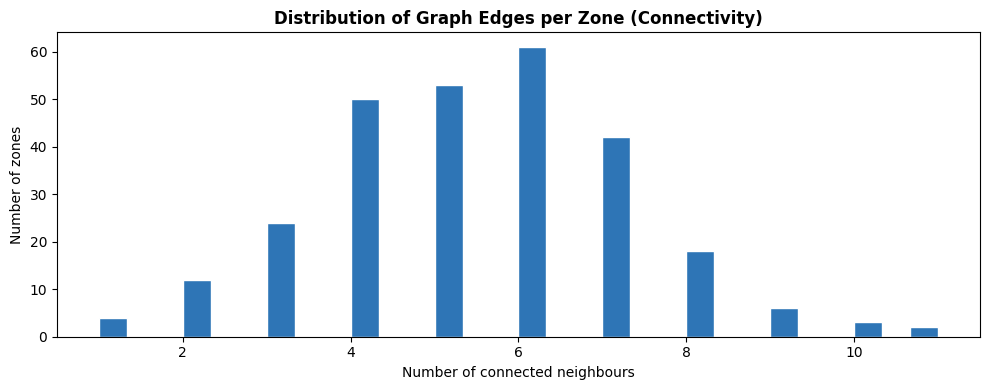

In [6]:
# Reload adj and distance correctly (no index column)
adj_raw      = pd.read_csv(f'{BASE}/adj.csv',      header=0)
distance_raw = pd.read_csv(f'{BASE}/distance.csv', header=0)

# Zone order from columns
adj_zones_ordered = [int(c) for c in adj_raw.columns]

# Verify order matches occupancy zones
print(f"Zones match occupancy order: {adj_zones_ordered == occ_zones}")

# Use values directly — already aligned
A = adj_raw.values.astype(float)
D = distance_raw.values.astype(float)

print(f"\nAdjacency matrix shape:  {A.shape}")
print(f"Distance matrix shape:   {D.shape}")
print(f"Non-zero edges in adj:   {int(A.sum())}")
print(f"Avg edges per zone:      {A.sum(axis=1).mean():.2f}")

# Connectivity distribution
plt.figure(figsize=(10, 4))
plt.hist(A.sum(axis=1), bins=30, color='#2E75B6', edgecolor='white')
plt.title('Distribution of Graph Edges per Zone (Connectivity)', fontweight='bold')
plt.xlabel('Number of connected neighbours')
plt.ylabel('Number of zones')
plt.tight_layout()
plt.savefig('graph_connectivity.png', dpi=150, bbox_inches='tight')
plt.show()

# Store aligned dataframes for Cell 7
adj_aligned  = pd.DataFrame(A, index=occ_zones, columns=occ_zones)
dist_aligned = pd.DataFrame(D, index=occ_zones, columns=occ_zones)

In [7]:
import os
os.makedirs('/kaggle/working/features', exist_ok=True)

# Save temporal features
temporal_features.to_csv('/kaggle/working/features/temporal_features.csv')

# Save POI features
poi_features.to_csv('/kaggle/working/features/poi_features.csv')

# Save aligned matrices
pd.DataFrame(A, index=occ_zones, columns=occ_zones).to_csv('/kaggle/working/features/adj_aligned.csv')
pd.DataFrame(D, index=occ_zones, columns=occ_zones).to_csv('/kaggle/working/features/dist_aligned.csv')

# Save zone info with coordinates
inf_zone.to_csv('/kaggle/working/features/inf_aligned.csv')

print("=== Feature Engineering Complete ===")
print(f"Temporal features:  {temporal_features.shape}")
print(f"POI features:       {poi_features.shape}")
print(f"Adjacency matrix:   {A.shape}")
print(f"Zones saved:        {len(occ_zones)}")
print("\nAll features saved to /kaggle/working/features/")
print("Hit Save Version → Save & Run All before closing.")

=== Feature Engineering Complete ===
Temporal features:  (4344, 11)
POI features:       (275, 8)
Adjacency matrix:   (275, 275)
Zones saved:        275

All features saved to /kaggle/working/features/
Hit Save Version → Save & Run All before closing.
